In [26]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import segmentation_models_pytorch as smp
from torchvision import transforms
from scipy import ndimage  # Essential for the shadow fix
import os
from glob import glob

from torchvision import transforms

import sys
import os

import cv2

# Move up one directory to the project root
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

# Now you can import your function
from src.get_satellite_image import get_aerial_image_tensor

from src.image_processing import refine_and_analyze

print("✅ Successfully imported get_aerial_image_tensor")

# --- Environment Setup ---
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# --- Load Your Refined Model ---
# We use the 'up-one-level' search we fixed earlier
try:
    model_path = glob("../models/final_refined_roof_model.pth", recursive=True)[0]
    print(f"✅ Found Model: {model_path}")
except IndexError:
    model_path = "models/final_refined_roof_model.pth" # Fallback to local folder

model = smp.Unet(encoder_name="resnet34", in_channels=3, classes=1).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

✅ Successfully imported get_aerial_image_tensor
Running on: mps
✅ Found Model: ../models/final_refined_roof_model.pth


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

📐 Roof Orientation: 93.33°
🧩 Corner Count: 4


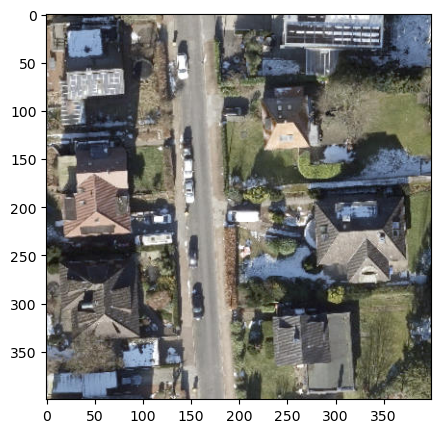

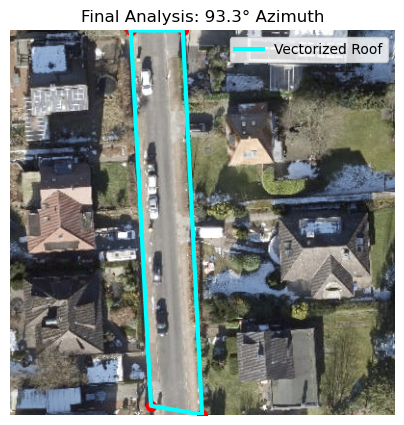

In [27]:
# --- SET COORDINATES HERE ---
lat, lon = 53.63206781, 10.0699501
# ----------------------------

# 1. Download (returns 0-1 tensor)
img_tensor = get_aerial_image_tensor(lat=lat, lon=lon, zoom=19, size=400, device=device)

# 2. Add the Missing Normalization (for the Model's eyes only)
# This matches what your model learned during training
model_preprocess = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], 
    std=[0.229, 0.224, 0.225]
)
# We apply it to a clone so we don't mess up the original for display
input_tensor = model_preprocess(img_tensor.squeeze(0)).unsqueeze(0)

# --- STEP 3: INFERENCE ---
model.eval()
with torch.no_grad():
    logits = model(input_tensor)
    # This is the raw output from the model
    mask = (torch.sigmoid(logits) > 0.5).float().squeeze().cpu().numpy()

# --- STEP 4: SHADOW FIX ---
mask_final = ndimage.binary_fill_holes(mask).astype(np.float32)
mask_final = ndimage.binary_closing(mask_final, structure=np.ones((3,3))).astype(np.float32)

# --- STEP 5: GEOMETRIC ANALYSIS ---
# Based on your latest image_processing.py function, 
# it returns: simplified_poly, azimuth, final_mask (3 items)
# The corner_count is just the length of the poly!

poly, angle, cleaned_mask = refine_and_analyze(mask_final)
corner_count = len(poly) if poly is not None else 0

# --- CONVERT TENSOR TO DISPLAY IMAGE ---
# 1. Remove the batch dimension (squeeze)
# 2. Move channels to the end (permute 1, 2, 0)
# 3. Move back to CPU and convert to numpy
display_img = img_tensor.squeeze().cpu().permute(1, 2, 0).numpy()

# 4. Clip values to 0-1 range to ensure colors are correct
display_img = np.clip(display_img, 0, 1)

# --- NOW THE PLOTTING WILL WORK ---
plt.figure(figsize=(5, 5))
plt.imshow(display_img)

# --- STEP 6: VISUALIZATION ---
print(f"📐 Roof Orientation: {angle:.2f}°")
print(f"🧩 Corner Count: {corner_count}")

plt.figure(figsize=(5, 5))
plt.imshow(display_img)

# Draw the simplified polygon
pts = poly.reshape(-1, 2)
# We add the first point to the end to close the shape
pts_closed = np.vstack([pts, pts[0]])
plt.plot(pts_closed[:,0], pts_closed[:,1], color='cyan', linewidth=3, label='Vectorized Roof')
plt.scatter(pts[:,0], pts[:,1], color='red', s=50) # Highlight corners

plt.legend()
plt.title(f"Final Analysis: {angle:.1f}° Azimuth")
plt.axis('off')
plt.show()

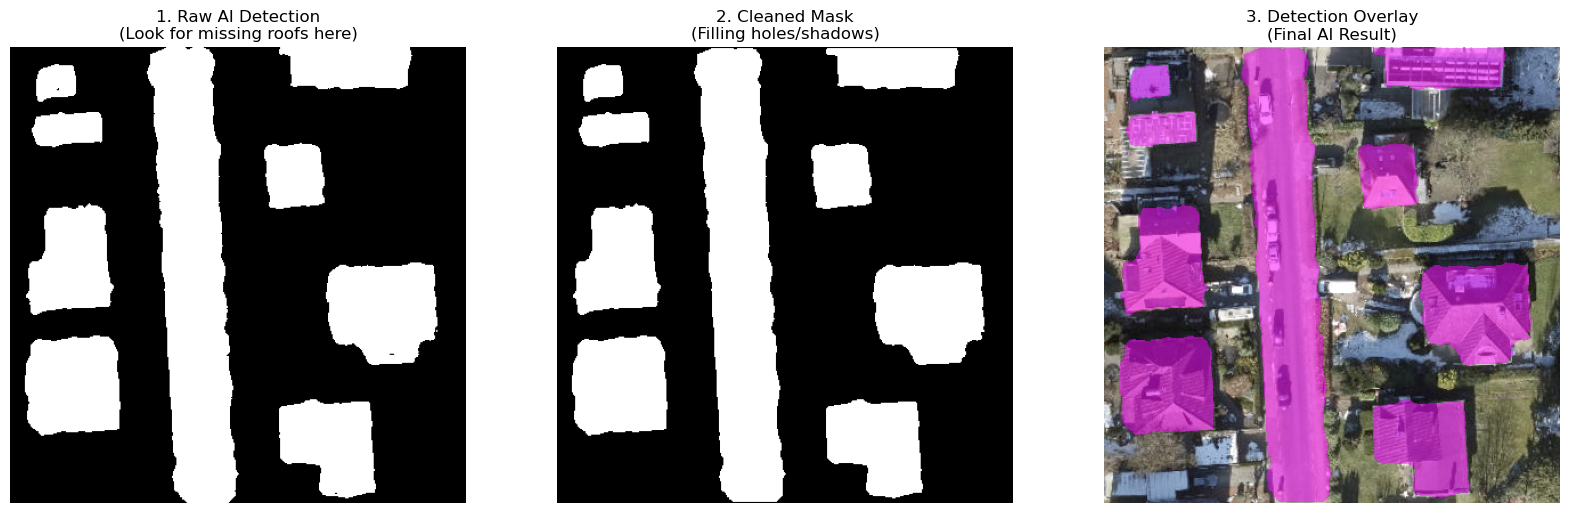

In [28]:
# 1. RUN INFERENCE
model.eval()
with torch.no_grad():
    logits = model(input_tensor)
    # DIAGNOSTIC TIP: Try lowering 0.5 to 0.3 if the big roof is faint
    mask = (torch.sigmoid(logits) > 0.5).float().squeeze().cpu().numpy()

# 2. PREP DISPLAY IMAGE
display_img = np.clip(img_tensor.squeeze().cpu().permute(1, 2, 0).numpy(), 0, 1)

# 3. SHOW DIAGNOSTIC PLOT
fig, ax = plt.subplots(1, 3, figsize=(20, 7))

# Panel 1: What the AI actually detected (Raw)
ax[0].imshow(mask, cmap='gray')
ax[0].set_title("1. Raw AI Detection\n(Look for missing roofs here)")
ax[0].axis('off')

# Panel 2: After Shadow Fix & Cleaning
from scipy import ndimage
mask_cleaned = ndimage.binary_fill_holes(mask).astype(np.float32)
mask_cleaned = ndimage.binary_closing(mask_cleaned, structure=np.ones((3,3))).astype(np.float32)
ax[1].imshow(mask_cleaned, cmap='gray')
ax[1].set_title("2. Cleaned Mask\n(Filling holes/shadows)")
ax[1].axis('off')

# Panel 3: Overlay on Original
ax[2].imshow(display_img)
overlay = np.ma.masked_where(mask_cleaned == 0, mask_cleaned)
ax[2].imshow(overlay, cmap='spring', alpha=0.5)
ax[2].set_title("3. Detection Overlay\n(Final AI Result)")
ax[2].axis('off')

plt.show()